In [1]:
import numpy as np
from numpy import array
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
#Extract relevant blocks for conditional distribution p(y1| y2 , y3, y4)
mu_a = 64
mu_b = array([[47],
              [101],
              [69]])

In [3]:
Sigma_aa = 800
Sigma_bb = array([[1430,2810,200],
                  [2810,17240,190],
                  [200,190,730]])

In [4]:
Sigma_ab = array([[260,1670,-30]])
y_b = array([[16],
             [14],
             [35]])

In [5]:
#Compute conditional mean and covariance for p(y1| y2 , y3, y4)
Sigma_bb_inv = np.linalg.inv(Sigma_bb)
mu_agb = (mu_a + Sigma_ab @ Sigma_bb_inv @ (y_b - mu_b)).item()
Sigma_agb = (Sigma_aa - Sigma_ab @ Sigma_bb_inv @ Sigma_ab.T).item()
print(mu_agb)
print(Sigma_agb)

57.77909922409359
635.0110089517148


In [6]:
#Cubone's actual health
cubone_health = 50

In [7]:
#Generate x1 values for plotting
x_line = np.linspace(mu_agb - 3*np.sqrt(Sigma_agb), 
                     mu_agb + 3*np.sqrt(Sigma_agb), 100)

In [8]:
#Compute probability density function
p_agb = norm.pdf(x_line, mu_agb, np.sqrt(Sigma_agb))

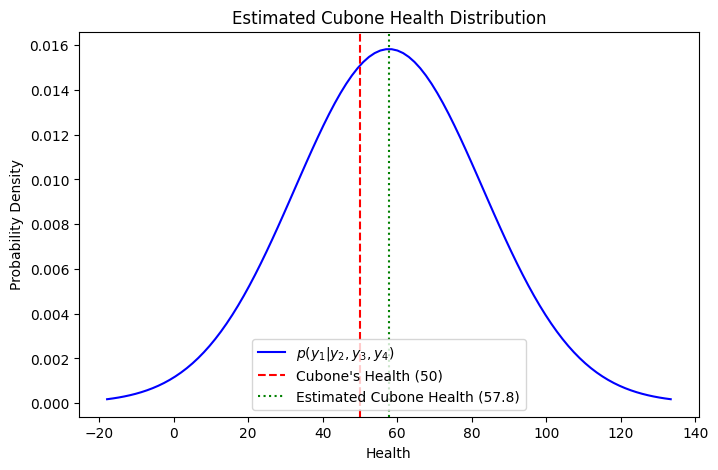

In [9]:
#Plot the estimated biological age distribution
plt.figure(figsize=(8, 5))
plt.plot(x_line, p_agb, label=r'$p(y_1 | y_2, y_3, y_4)$', color='blue')
#Vertical line for Cubone's actual health
plt.axvline(x=cubone_health, color='red', linestyle='--', label="Cubone's Health (50)")
#Vertical line for estimated health
plt.axvline(x=mu_agb, color='green', linestyle=':', label="Estimated Cubone Health (57.8)")
plt.xlabel("Health")
plt.ylabel("Probability Density")
plt.title("Estimated Cubone Health Distribution")
plt.legend()
plt.show();

In [10]:
# Correlation between pokemon health and weight
rho_13 = 1670 / (np.sqrt(800) * np.sqrt(17240))
print(rho_13)

0.4496792489254459


In [11]:
from scipy.stats import multivariate_normal
import plotly.graph_objects as go

In [12]:
#Extract relevant blocks for conditional distribution p(x2, x3 | x1, x4)
mu_a = array([[47],
              [101]])
mu_b = array([[64],
              [69]])

In [13]:
Sigma_aa = array([[1430,2810],
                  [2810,17240]])

In [14]:
Sigma_bb = array([[800,-30],
                  [-30,730]])

In [15]:
Sigma_ab = array([[260,200],
                  [1670,190]])

In [16]:
y_a = array([[16],
             [14]]) # Cubone's actual height and weight (for plotting later)
y_b = array([[50],
             [35]])

In [17]:
#Compute conditional mean and covariance for p(y2, y3| y1, y4)
Sigma_bb_inv = np.linalg.inv(Sigma_bb)
mu_agb = (mu_a + Sigma_ab @ Sigma_bb_inv @ (y_b - mu_b))
Sigma_agb = (Sigma_aa - Sigma_ab @ Sigma_bb_inv @ Sigma_ab.T)
print(mu_agb)
print(Sigma_agb)

[[32.51466301]
 [59.80878066]]
[[ 1285.13977019  2194.5515349 ]
 [ 2194.5515349  13666.31624078]]


In [18]:
# Generate grid
# Cubone is small, so we'll zoom in, but you can adjust the bounds to zoom out
x2_vals = np.arange(-50, 200, 1)
x3_vals = np.arange(-50, 200, 1)
X2, X3 = np.meshgrid(x2_vals, x3_vals)

In [19]:
#Compute the probability density function
rv = multivariate_normal(mean = mu_agb.flatten(), cov=Sigma_agb)

# Compute density values
pos = np.dstack((X2, X3))
py_values = rv.pdf(pos)

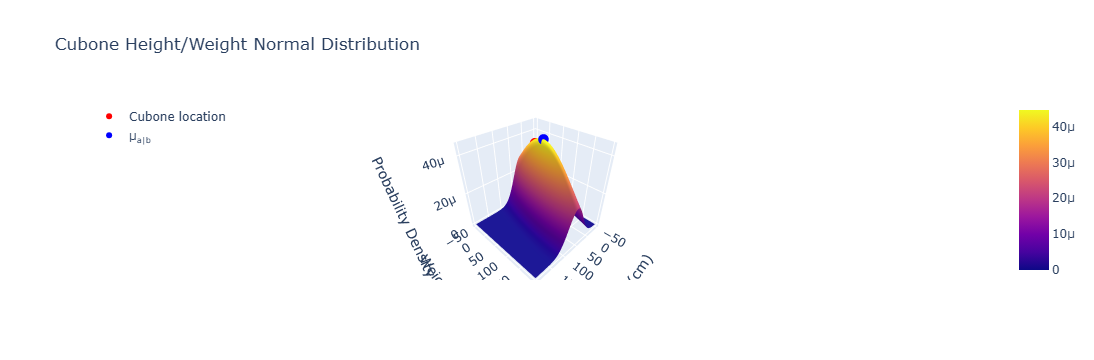

In [20]:
# Create 3D surface plot
fig = go.Figure(data=[go.Surface(z=py_values, x=x2_vals, y=x3_vals)])
fig.update_layout(title="Cubone Height/Weight Normal Distribution", scene=dict(xaxis_title="X2", yaxis_title="X3", zaxis_title="Density"))
#Plot Cubone's location
cubone_pdf_value = rv.pdf(y_a.flatten())
fig.add_trace(go.Scatter3d(
    x=[y_a[0, 0]], 
    y=[y_a[1, 0]], 
    z=[cubone_pdf_value], 
    mode='markers',
    marker=dict(size=6, color='red'),
    name="Cubone location"
))
#And the mean
fig.add_trace(go.Scatter3d(
    x=[mu_agb[0, 0]], 
    y=[mu_agb[1, 0]], 
    z=[rv.pdf(mu_agb.flatten())], 
    mode='markers',
    marker=dict(size=6, color='blue'),
    name="μ<sub>a|b</sub>"
))
fig.update_layout(
    title="Cubone Height/Weight Normal Distribution",
    scene=dict(
        xaxis_title="Height (cm)", 
        yaxis_title="Weight (kg)", 
        zaxis_title="Probability Density"
    ),
    legend=dict(
        x=0.01,  # Left side (0 = far left, 1 = far right)
        y=0.99,  # Top (0 = bottom, 1 = top)
        xanchor='left',
        yanchor='top'
    )
)